### Evasion dataset 

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression
import joblib
import yaml
from pathlib import Path


In [3]:
# configs 
my_font = dict(
            family="Courier New, monospace",
            size=18,
            color="Black",
            variant="small-caps",
) 

## Loading datasets

In [4]:
"""
Loading the datasets

"""
def get_config_file(): 
    try:
        base_dir = Path(__file__).resolve().parent.parent
        path = base_dir / "configs" / "training.yaml"
        return path
    except NameError: # if it is a jupyter file 
        return Path("/training-app/configs/training.yaml")


def load_config(CONFIG_PATH) :
  """
  Selects the current dataset's config file we are interest in.
  """
  try:
      with open(CONFIG_PATH, "r") as f:
        full_config = yaml.safe_load(f)
  except Exception as e:
    print(f"Config file not found {e}")
    raise


  try:
    current_dataset = full_config["CURRENT_DATASET"]
    print(f"\nloading current dataset: {current_dataset}")
    if current_dataset not in full_config['DATASETS']:
      raise ValueError(f"\nDataset {current_dataset} not found!")

    return full_config["DATASETS"][current_dataset]

  except Exception as e:
    print(f"There was an error handling the config cleaning.yaml file {e}")
    raise


CONFIG_PATH = get_config_file()
dfs = load_config(CONFIG_PATH)


loading current dataset: CIENCIA_DA_COMPUTACAO


### Selecting desired dataset -> df_train


In [5]:
"""
Selecting desired dataset -> df_train
"""
df_active = pd.read_csv(dfs['ACTIVE_DATASET'])
df_deactive = pd.read_csv(dfs['EVADED_DATASET'])
df_history = pd.read_csv(dfs['HISTORY_DATASET'])

## Checking the general info of the dataset

We need to extract the following features:
    - For each semester, we need to calculate the CR - Coeficiente de Rendimento
    - The total Amount of failings per semester 
    - The total Diciplines made per semester (Credits)
    - CR_Trend - Change in CR from last semester (Coeficiente)
    - Failure_rate - % of subjects failed so far
    - % of subjects failed so far
    - Delayed_Progress	Are they behind schedule?


- We must create the Lag_Academico
  - Tempo_de_Permanenca - Idade_Academica 
    - Lag 0   -> The student is on track
    - Lag > 2 -> The student is behind
    - Lag < 0 -> The student is an overachiever 

- We can also create the Velocidade_Progresso
  - ( Idade_Academica / Tempo_de_Permanencia )  
  - 1.0 -> velocidade ok
  - 0.5 -> Student taking 2x to finish the classes

## Handling History dataset - this later on will be a dag in airflow

In [388]:
df_history_v0 = df_history.copy()
def calculate_ano_sem(df: pd.DataFrame) -> pd.DataFrame:
    df['Ano']  = df['AnoSem'].astype('int')
    df['Parcela'] = df['Semestre'] / 10
    if 'AnoSem' in df.columns:
        df.drop(columns={'AnoSem'}, inplace=True)
    df['AnoSem'] = df['Ano'] + df['Parcela']
    df = df.drop('Parcela', axis=1)
    return df
df_history_v0 = calculate_ano_sem(df_history_v0)






df_history_v0 = df_history_v0.sort_values(by='RGA_Anon')
df_history_v0.drop(columns={"Faltas", "Codigo_Turma", "Equivalencia", "Codigo_Disciplina", "Curso_Ofertante", "Observacao", "Ano", 'Idade_Academica'}, inplace=True)

"""
Here, we will need the - Período ingresso - feature to calculate the permanence time
"""

all_students = pd.concat([df_active, df_deactive], axis=0)
df_history_v0 = df_history_v0.merge(all_students[['RGA_Anon', 'Período ingresso', 'Estrutura', 'Situação atual']], on='RGA_Anon', how='left')


df_history_v0['Nome_Disciplina'] = (
    df_history_v0['Nome_Disciplina']
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
    .str.upper()
    .str.strip()
)

df_history_v0['Nome_Disciplina'] = df_history_v0['Nome_Disciplina'].str.replace(r'\(OPTATIVA\)', '', regex=True).str.strip()



### done. 

In [389]:
def eliminating_duplicates_ap_ae(df: pd.DataFrame) -> pd.DataFrame:

    ae_ap_pairs = df.groupby(['RGA_Anon', 'Nome_Disciplina']) \
        .filter(lambda g: {'AP', 'AE'}.issubset(set(g['Situação'])))

    df_adjust = df.copy()

    nota_ap = ae_ap_pairs[ae_ap_pairs['Situação'] == 'AP'] \
        .groupby(['RGA_Anon', 'Nome_Disciplina'])['Nota'].max()

    mask_ae = (df_adjust['Situação'] == 'AE') & (
        df_adjust.set_index(['RGA_Anon', 'Nome_Disciplina']).index.isin(nota_ap.index)
    )

    df_adjust.loc[mask_ae, 'Nota'] = df_adjust.loc[mask_ae].set_index(
        ['RGA_Anon', 'Nome_Disciplina']
    ).index.map(nota_ap)

    mask_ap_to_drop = (df_adjust['Situação'] == 'AP') & (
        df_adjust.set_index(['RGA_Anon', 'Nome_Disciplina']).index.isin(nota_ap.index)
    )

    df_adjust = df_adjust[~mask_ap_to_drop].copy()
    return df_adjust

df_history_v0 =  eliminating_duplicates_ap_ae(df_history_v0)


In [390]:
def setting_subject_faiulures (df: pd.DataFrame) -> pd.DataFrame: 
    """
    Convert subject status into a binary outcome:
    - 1 = failure in a subject
    - 0 = non-failure
    Rows with 'MA' status are excluded.
    """
    df = df.copy()
    df = df[df['Situação'] != "MA"]
    failures = ['RMF', 'RM', 'RP', 'RF']

    df['Situação']  = np.where(
        df['Situação'].isin(failures),
        1,
        0
    )
    return df 


df_history_v0 = setting_subject_faiulures(df_history_v0)

In [391]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3081 entries, 0 to 3900
Data columns (total 35 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Sexo                                  3081 non-null   object 
 1   Raça                                  3081 non-null   object 
 2   Naturalidade                          3044 non-null   object 
 3   UF Naturalidade                       2919 non-null   object 
 4   Periodo_Atual                         3081 non-null   float64
 5   Situação atual_x                      3081 non-null   object 
 6   Estrutura                             3081 non-null   int64  
 7   Período ingresso                      3081 non-null   float64
 8   Tipo ingresso                         3081 non-null   object 
 9   IMI                                   3081 non-null   float64
 10  Tipo de demanda                       1909 non-null   object 
 11  RGA_Anon              

In [392]:
"""
Here we calculate the weighted faiulure - Reprovacao_Ponderada_Semestral - How many credits did the student fail
"""
def calculate_weighted_failured( df: pd.DataFrame) -> pd.DataFrame:
    
    df['Reprovacao_Ponderada_Semestral'] = df["Crédito"].to_numpy() * df["Situação"].to_numpy()

    df['Reprovacao_Ponderada_Semestral'] = (
        df.groupby(["AnoSem",  "RGA_Anon"])["Reprovacao_Ponderada_Semestral"]
        .transform("sum")
    )

    return df
df_history_v2 = df_history_v0.copy()
df_history_v2 = calculate_weighted_failured(df_history_v2)

In [393]:
"""
Here we calculate - [Reprovação_Media_Semestral] - how much percent of the total credits taken does the student fail

    - 0.0 -> student did not fail a single one subject
    - 1.0 -> student failed all subjects
"""
def calculate_failure_ratio (df: pd.DataFrame) -> pd.DataFrame:
    total_credit = df.groupby(["AnoSem",  "RGA_Anon"])['Crédito'].transform("sum").to_numpy() 
    total_credit = total_credit.astype("float")

    df['Reprovacao_Ponderada_Semestral'] = df['Reprovacao_Ponderada_Semestral'].astype("float")
    
    df['Reprovação_Media_Semestral']  = (df['Reprovacao_Ponderada_Semestral'].to_numpy()  / total_credit)
    # df.drop(columns={'Reprovacao_Ponderada_Semestral'}, inplace=True)
    df = df.drop('Reprovacao_Ponderada_Semestral', axis=1)
    return df
df_history_v3 = df_history_v2.copy()
df_history_v3 = calculate_failure_ratio(df_history_v3)



/tmp/ipykernel_9/333863791.py:13: RuntimeWarning: invalid value encountered in divide
  df['Reprovação_Media_Semestral']  = (df['Reprovacao_Ponderada_Semestral'].to_numpy()  / total_credit)


In [394]:
# def calculate_failure_ratio (df: pd.DataFrame) -> pd.DataFrame:

#     df['Reprovacao_Ponderada_Semestral'] = df["Crédito"]* df["Situação"]

#     df['Reprovacao_Ponderada_Semestral'] = (
#             df.groupby(["AnoSem",  "RGA_Anon"])["Reprovacao_Ponderada_Semestral"]
#                 .transform("sum")
#     )

#     total_credit = df.groupby(["AnoSem",  "RGA_Anon"])['Crédito'].transform("sum")
#     total_credit = total_credit.astype("float")
#     df['Reprovacao_Ponderada_Semestral'] = df['Reprovacao_Ponderada_Semestral'].astype("float")
        
#     df['Reprovação_Media_Semestral']  = (df['Reprovacao_Ponderada_Semestral'] / total_credit)
#     df.drop(columns={'Reprovacao_Ponderada_Semestral'}, inplace=True)

#     return df

# df_history_v3 = df_history_v0.copy()
# df_history_v3 = calculate_failure_ratio(df_history_v3)


In [395]:
df_history_v4 = df_history_v3.copy()
periodo_ingresso = sorted(df_history_v4['Período ingresso'].unique())

print("As noted, we have an entrance date starting in 2009. But, at the same time, we got disciplines happening already in 2006")
# display(periodo_ingresso)

all_ano = sorted(df_history_v4['AnoSem'].unique())
# display(all_ano)

print("We must therefore drop all the history that happened before 2009")


As noted, we have an entrance date starting in 2009. But, at the same time, we got disciplines happening already in 2006
We must therefore drop all the history that happened before 2009


In [396]:
"""
Here, we will get only the semesters starting from 2009.1
"""
def selecting_valid_period(df: pd.DataFrame) -> pd.DataFrame:
   return df[df['AnoSem'] >= 2009.1].copy()

df_history_v5 = df_history_v4.copy()
df_history_v5 = selecting_valid_period(df_history_v5)

In [397]:
"""
Now we enumerate these semesters in order to calculate the total number of semesters
the student has been enrolled since admission.
"""

def calculate_permanence_period_in_semesters(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Ensure Período ingresso is float and convert to decimal
    df['Período ingresso'] = df['Período ingresso'].astype(float) / 10

    # Cap any fractional semester > 2 to 2 (e.g., 2024.3 -> 2024.2)
    def cap_sem(x):
        int_part = int(x)
        frac_part = int(round((x - int_part) * 10))
        frac_part = min(frac_part, 2)  # cap to 2
        return float(f"{int_part}.{frac_part}")

    df['AnoSemCap'] = df['AnoSem'].apply(cap_sem)
    df['Período ingresso Cap'] = df['Período ingresso'].apply(cap_sem)

    # Create chronological mapping
    all_values = pd.concat([df['AnoSemCap'], df['Período ingresso Cap']]).dropna().unique()
    mapping = {val: i+1 for i, val in enumerate(sorted(all_values))}

    # Map to ordered IDs
    df['AnoSemIdOrdered'] = df['AnoSemCap'].map(mapping)
    df['PeriodoIngressoIdOrdered'] = df['Período ingresso Cap'].map(mapping)

    # Calculate permanence in semesters
    df['Tempo_Permanencia_Em_Semestres'] = df['AnoSemIdOrdered'] - df['PeriodoIngressoIdOrdered'] + 1

    # Drop helper columns
    df.drop(columns=['AnoSemIdOrdered', 'PeriodoIngressoIdOrdered', 'AnoSemCap', 'Período ingresso Cap'], inplace=True)
    
    return df

# Apply to your dataset
df_history_v6 = df_history_v5.copy()
df_history_v6 = calculate_permanence_period_in_semesters(df_history_v6)

In [398]:
df_history_v6.drop_duplicates(['RGA_Anon', 'Nome_Disciplina', 'Nota'], inplace=True)
aluno = df_history_v6[df_history_v6['RGA_Anon'] == 'cebd2a22d53bdbee3fc8fae36a980d188780759c2bf51a784c02ccaeaecfb406']
aluno.sort_values(by='Tempo_Permanencia_Em_Semestres', inplace=True)
aluno[[ 'Tempo_Permanencia_Em_Semestres', 'Semestre', 'Nome_Disciplina', 'AnoSem']]

/tmp/ipykernel_9/2555295854.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aluno.sort_values(by='Tempo_Permanencia_Em_Semestres', inplace=True)


,Tempo_Permanencia_Em_Semestres,Semestre,Nome_Disciplina,AnoSem
18195,1,1,INTRODUCAO A COMPUTACAO,2023.1
18196,1,1,LOGICA DIGITAL,2023.1
18198,1,1,PROGRAMACAO DE COMPUTADORES,2023.1
18194,1,1,GEOMETRIA ANALITICA E VETORIAL,2023.1
18212,1,1,CALCULO I,2023.1
18201,1,1,ELETRONICA BASICA,2023.1
18193,2,2,ESTRUTURA DE DADOS I,2023.2
18200,2,2,ARQUITETURA DE COMPUTADORES,2023.2
18199,2,2,ALGEBRA LINEAR I,2023.2
18202,2,2,CALCULO II,2023.2


In [399]:

df_history_v6_01 = df_history_v6.copy()



def calculate_total_accumulated_credits(df: pd.DataFrame) -> pd.DataFrame: 

    mapping = {
        20241: 210,
        20191: 200,
        20091: 211
    }

    df['Total_creditos_estrutura'] = df['Estrutura'].map(mapping)

    resumo_creditos = df[df['Situação'] == 0] \
    .groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Crédito'] \
    .sum() \
    .reset_index()


    resumo_creditos['Total_Creditos_Acumulados'] = resumo_creditos.groupby('RGA_Anon')['Crédito'].cumsum()
    df = df.merge(
        resumo_creditos[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Total_Creditos_Acumulados']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )

    return df


df_history_v6_01 = calculate_total_accumulated_credits(df_history_v6_01)

In [400]:

def calculate_normalized_academic_age(df):
    # 1. Definir os limites por estrutura (ajuste os valores conforme sua realidade)
    metas = {
        20091: {'min_credits': 211, 'ideal_semesters': 8},
        20191: {'min_credits': 200, 'ideal_semesters': 8},
        20241: {'min_credits': 210, 'ideal_semesters': 8}
    }

    df = df.copy()
    
    def get_age(row):
        struct = row['Estrutura']
        if struct not in metas: return row['Tempo_Permanencia_Em_Semestres'] # fallback
        
        meta = metas[struct]
        progresso = min(1.0, row['Total_Creditos_Acumulados'] / meta['min_credits'])
        
        return progresso * meta['ideal_semesters']

    df['Idade_Academica'] = df.apply(get_age, axis=1)
    df['Estrutura'] = df['Estrutura'].astype(int)

    
    return df
df_history_v7 = df_history_v6_01.copy()
df_history_v7 = calculate_normalized_academic_age(df_history_v7)

In [401]:
""" Now we will calculate the academic lag """

def calculate_academic_lag_in_semesters(df: pd.DataFrame) -> pd.DataFrame: 
    df = df.copy()
    df = df.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    df['Tempo_Permanencia_Em_Semestres'] = df['Tempo_Permanencia_Em_Semestres'].astype(float)
    df['Idade_Academica'] = df['Idade_Academica'].astype(float)
    df['Lag_Academico_Em_Semestres'] = df.groupby('RGA_Anon').apply(
    lambda g: g['Tempo_Permanencia_Em_Semestres'] - g['Idade_Academica']
).reset_index(level=0, drop=True)
    return df

df_history_v7_01= df_history_v7.copy()
df_history_v7_01 = calculate_academic_lag_in_semesters(df_history_v7_01)

/tmp/ipykernel_9/3120955355.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['Lag_Academico_Em_Semestres'] = df.groupby('RGA_Anon').apply(


In [402]:

# aluno = df_history_v7_01[df_history_v7_01['RGA_Anon'] == 'cebd2a22d53bdbee3fc8fae36a980d188780759c2bf51a784c02ccaeaecfb406']
# aluno.sort_values(by='Tempo_Permanencia_Em_Semestres', inplace=True)


# aluno[['Idade_Academica', 'Tempo_Permanencia_Em_Semestres', 'Lag_Academico_Em_Semestres']]

In [403]:
def calculate_deltas_fixed(df: pd.DataFrame) -> pd.DataFrame:


    df = df.copy()
    # 1. Ensure chronological order
    df = df.sort_values(by=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])


    sem_snapshot = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres']).agg({
        'Lag_Academico_Em_Semestres': 'first',
        'MG_Semestre': 'first'
    }).reset_index()

    sem_snapshot['Lag_Academico_Delta'] = sem_snapshot.groupby('RGA_Anon')['Lag_Academico_Em_Semestres'].diff().fillna(0)


    df = df.drop(columns=['Lag_Academico_Delta'], errors='ignore') # Clean up if they exist
    df = df.merge(
        sem_snapshot[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Lag_Academico_Delta']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    
    return df
df_history_v8 = df_history_v7_01.copy()
df_history_v8 = calculate_deltas_fixed(df_history_v8)

In [404]:
""""
Here we define if the student suffered from the pandemic
"""

def mark_pandemic(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    def classify(x):
        if 2020.1 <= x <= 2021.2:
            return 'Remoto'
        elif 2022.1 <= x <= 2022.2:
            return 'Hibrido'
        else:
            return 'Presencial'

    df['Modalidade_Ensino'] = df['AnoSem'].apply(classify)

    return df


In [405]:
""" Now we will calculate the CR - Coeficiente de Rendimento - per semester
    Fórmula:  (Soma de Nota x Crédito) / (Soma dos Créditos)
"""

def calculate_coeficiente(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    # numerator of the division
    df['NC_Materia'] = df['Nota'] * df['Crédito']
    
    # a summary for each semester
    resumo_semestral = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres']).agg({
        'NC_Materia': 'sum',
        'Crédito': 'sum'
    }).reset_index()
    
    # now we sum all the previous NC and the credits from previous semesters 
    resumo_semestral['NC_Acumulado'] = resumo_semestral.groupby('RGA_Anon')['NC_Materia'].cumsum()
    resumo_semestral['Creditos_Acumulados'] = resumo_semestral.groupby('RGA_Anon')['Crédito'].cumsum()
    
    # coefficient up until that semester
    resumo_semestral['Coeficiente_Rendimento'] = (
        resumo_semestral['NC_Acumulado'] / resumo_semestral['Creditos_Acumulados']
    )
    
    if 'Coeficiente_Rendimento' in df.columns:
        df = df.drop(columns=['Coeficiente_Rendimento'])
        
    df = df.merge(
        resumo_semestral[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Coeficiente_Rendimento']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    
    # Limpeza de colunas técnicas
    df.drop(columns=['NC_Materia'], inplace=True)
    
    return df


def calculate_coefficient_delta(df: pd.DataFrame) -> pd.DataFrame:
    df= df.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])

    snapshot = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres']).first().reset_index()
    snapshot['Coeficiente_Rendimento_Delta'] = snapshot.groupby('RGA_Anon')['Coeficiente_Rendimento'].diff().fillna(0)

    if 'Coeficiente_Rendimento_Delta' in df.columns:
        df = df.drop('Coeficiente_Rendimento_Delta', axis=1)

    df = df.merge(snapshot[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Coeficiente_Rendimento_Delta']],
                    on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
                    how='left')
    return df 



df_history_v9= df_history_v8.copy()
df_history_v9 = calculate_coeficiente(df_history_v9)
df_history_v9 = calculate_coefficient_delta(df_history_v9)
df_history_v9 = mark_pandemic(df_history_v9)


In [406]:
"""
Here we will calculate the academic performance efficiency of this student.

    eficiencia_academica = (idade_academica) / (tempo_de_permanencia) 

    1.0 -> perfect, they are progressing as expected
    0.5 -> student taking twice as long as expected
"""

def academic_efficiency(df: pd.DataFrame) -> pd.DataFrame: 
    df['Eficiencia_Academica'] = df['Idade_Academica'] / df['Tempo_Permanencia_Em_Semestres']
    return df 

df_history_v10 = df_history_v9.copy()
df_history_v10= academic_efficiency(df_history_v10)

In [407]:
df_history_v10[['Eficiencia_Academica', 'Situação', 'Tempo_Permanencia_Em_Semestres', 'Idade_Academica', 'Crédito', 'Estrutura']].head(15)

,Eficiencia_Academica,Situação,Tempo_Permanencia_Em_Semestres,Idade_Academica,Crédito,Estrutura
0,0.24,1,1.0,0.24,4,20191
1,0.24,1,1.0,0.24,6,20191
2,0.24,0,1.0,0.24,6,20191
3,0.24,1,1.0,0.24,6,20191
4,4.00,1,2.0,8.00,6,20191
5,4.00,1,2.0,8.00,6,20191
6,4.00,1,2.0,8.00,6,20191
7,4.00,1,2.0,8.00,4,20191
8,0.24,0,3.0,0.72,6,20191
9,0.24,1,3.0,0.72,6,20191


In [408]:

""" Lag feature for the acdemic efficiency of the student"""

def calculate_different_academic_efficiency_lags(df: pd.DataFrame) -> pd.DataFrame:

    pula_Semestre = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Eficiencia_Academica'].first().reset_index()
    grouped = pula_Semestre.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    ## shift 1 - lag 1 
    grouped['Eficiencia_Academica_Lag_01'] = grouped.groupby('RGA_Anon')['Eficiencia_Academica'].shift(1)
    grouped['Eficiencia_Academica_Lag_02'] = grouped.groupby('RGA_Anon')['Eficiencia_Academica'].shift(2)
    grouped['Eficiencia_Academica_Lag_03'] = grouped.groupby('RGA_Anon')['Eficiencia_Academica'].shift(3)


    cols_to_drop = ['Eficiencia_Academica_Lag_03','Eficiencia_Academica_Lag_02', 'Eficiencia_Academica_Lag_01' ]

    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    df = df.merge(
        grouped [['RGA_Anon', 'Tempo_Permanencia_Em_Semestres','Eficiencia_Academica_Lag_03','Eficiencia_Academica_Lag_02', 'Eficiencia_Academica_Lag_01'] ],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    return df

In [409]:
df_history_v11 = df_history_v10.copy()
df_history_v11 = calculate_different_academic_efficiency_lags(df_history_v11)

In [410]:
"""Here we calculate the rolling feature of 3 semesters back of a student"""

def calculate_rolling_failure(df: pd.DataFrame, window: int = 3) -> pd.DataFrame:
    resumo = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Reprovação_Media_Semestral'].first().reset_index()
    resumo = resumo.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])

    # rolling mean
    resumo['Rolling_Reprovacao_Media_3_Semestres'] = resumo.groupby('RGA_Anon')['Reprovação_Media_Semestral'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )

    if 'Rolling_Reprovacao_Media_3_Semestres' in df.columns:
        df = df.drop(columns=['Rolling_Reprovacao_Media_3_Semestres'])
        
    df = df.merge(
        resumo[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Rolling_Reprovacao_Media_3_Semestres']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    return df

In [411]:
df_history_v12 = df_history_v11.copy()
df_history_v12 = calculate_rolling_failure(df_history_v12, window=3)

In [412]:
"""
Here we calculate if the student has fallen behind any gatekeeper subjects 
"""

def apply_gatekeeper_feature(df, gatekeepers): 
    # 1. Identificação individual (Linha a linha)
    df['Eh_Gatekeeper'] = df['Nome_Disciplina'].isin(gatekeepers)
    df['Reprovou_Gatekeeper_Puro'] = ((df['Eh_Gatekeeper'] == True) & (df['Situação'] == 1)).astype(int)
    
    # 2. Total de falhas NESTE semestre
    # Se ele reprovou em 4, aqui teremos o número 4 para todas as linhas do semestre
    df['Qtd_Falhas_Gatekeeper_No_Semestre'] = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Reprovou_Gatekeeper_Puro'].transform('sum')
    
    # 3. Criar resumo para o cálculo acumulado (1 linha por semestre)
    resumo_semestral = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Qtd_Falhas_Gatekeeper_No_Semestre'].first().reset_index()
    resumo_semestral = resumo_semestral.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    
    # 4. Soma Acumulada Real
    # Aqui, se o Semestre 1 teve 4 falhas e o Semestre 2 teve 1, o acumulado será 5.
    resumo_semestral['Total_Falhas_Gatekeeper_Acumulado'] = resumo_semestral.groupby('RGA_Anon')['Qtd_Falhas_Gatekeeper_No_Semestre'].cumsum()
    
    # 5. Merge de volta para o DF principal
    if 'Total_Falhas_Gatekeeper_Acumulado' in df.columns:
        df.drop(columns=['Total_Falhas_Gatekeeper_Acumulado'], inplace=True)
        
    df = df.merge(
        resumo_semestral[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Total_Falhas_Gatekeeper_Acumulado']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )

    # Limpeza
    df.drop(columns={'Eh_Gatekeeper', 'Qtd_Falhas_Gatekeeper_No_Semestre'}, inplace=True)
    return df

df_history_v13 = df_history_v12.copy()
gatekeepers_list = ['ESTRUTURA DE DADOS I', 'CALCULO I', 'CALCULO DIFERENCIAL E INTEGRAL I', 'GEOMETRIA ANALITICA E VETORIAL', 
                               'PROGRAMACAO I', 'PROGRAMACAO DE COMPUTADORES', 'LÓGICA DIGITAL', 'LOGICA MATEMATICA E ELEMENTOS DE LOGICA DIGITAL',
                               'ARQUITETURA DE COMPUTADORES', 'FUNDAMENTOS DE MATEMATICA', 'MECANICA', 'ARQUITETURA E ORGANIZACAO DE COMPUTADORES']
df_history_v13 = apply_gatekeeper_feature(df_history_v13, gatekeepers_list)

In [413]:
""" The attendance trend of a student """
def calculate_attendance_trends(df: pd.DataFrame) -> pd.DataFrame:
    resumo = df.groupby(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])['Frequencia'].mean().reset_index()
    resumo = resumo.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
    
    # 2. Lag 1 (Frequência do semestre passado)
    resumo['Frequencia_Lag_01'] = resumo.groupby('RGA_Anon')['Frequencia'].shift(1)
    
    # 3. Tendência (Delta): Negativo = Aluno está faltando mais
    resumo['Frequencia_Trend'] = resumo['Frequencia'] - resumo['Frequencia_Lag_01']
    
    resumo['Frequencia_Rolling_3S'] = resumo.groupby('RGA_Anon')['Frequencia'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )
    
    df = df.merge(
        resumo[['RGA_Anon', 'Tempo_Permanencia_Em_Semestres', 'Frequencia_Trend', 'Frequencia_Rolling_3S']],
        on=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'],
        how='left'
    )
    return df

In [414]:
df_history_v14 = df_history_v13.copy()
df_history_v14 = calculate_attendance_trends(df_history_v14) 

In [415]:
"""Dropping the useless columns"""
df_history_v15= df_history_v14.copy()
df_history_v15 = df_history_v15.drop(columns={'Reprovou_Gatekeeper_Puro','Frequencia','Percentual_Faltas', 'CH', 'Semestre', 'Falta_Excessiva', 'Nome_Disciplina', 'Nota', 'Situação', 'Qtd_Disciplinas_Semestre', 'MG_Semestre', 'Total_CH_Semestre', 'Crédito'})
df_history_v15 = df_history_v15.drop_duplicates()

In [430]:
# df_test = df_history_v0.copy()
# df_test = df_test[df_test['AnoSem'] >= 2009.1]

# ### Eu quero contar quantas linhas unicas de RGA_Anon e AnoSem -> combinados tem na base de dados 

# df_test.groupby(['AnoSem','RGA_Anon']).size().reset_index()

In [431]:
df_history_v15.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3844 entries, 0 to 19796
Data columns (total 23 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RGA_Anon                              3844 non-null   object 
 1   AnoSem                                3844 non-null   float64
 2   Período ingresso                      3844 non-null   float64
 3   Estrutura                             3844 non-null   int64  
 4   Situação atual                        3844 non-null   object 
 5   Reprovação_Media_Semestral            3816 non-null   float64
 6   Tempo_Permanencia_Em_Semestres        3844 non-null   float64
 7   Total_creditos_estrutura              3844 non-null   int64  
 8   Total_Creditos_Acumulados             2926 non-null   float64
 9   Idade_Academica                       3844 non-null   float64
 10  Lag_Academico_Em_Semestres            3844 non-null   float64
 11  Lag_Academico_Delta  

In [432]:
"""Removing duplicates"""
df_history_v15.to_csv('test2.csv', index=False)

### Preparando o dataset dos estudantes

In [433]:
df_all_students = pd.concat([df_active, df_deactive])

df_all_students = df_all_students.rename(columns={"Período": "Periodo_Atual"})

df_all_students['Periodo_Atual'] = df_all_students['Periodo_Atual'] / 10

df_all_students['Estrutura'] = df_all_students['Estrutura'] .astype('int')

df_all_students['Data Nascimento'] = pd.to_datetime(df_all_students['Data Nascimento'])


df_all_students['Período ingresso'] = df_all_students['Período ingresso'] / 10 

df_all_students['Ano_Ingresso'] = np.floor(df_all_students['Período ingresso'])

df_all_students['Idade_Ingresso'] = df_all_students['Ano_Ingresso'] - df_all_students['Data Nascimento'] .dt.year

df_all_students = df_all_students.drop(columns={'Coeficiente', 'Estrangeiro', 'Nacionalidade', 'Estado Civil','Data Nascimento', 'Data ocorrência', 'Ano_Ingresso'})


In [439]:
""" keep the history of all students and bring them from the X dataset"""

df_full = df_history_v15.merge(df_all_students[['RGA_Anon', 'Período ingresso', 'Estrutura','Sexo', 'Raça', 'Periodo_Atual', 'Tipo ingresso', 'IMI', 'Tipo de demanda', 'Idade_Ingresso']],
                                on=['RGA_Anon', 'Período ingresso', 'Estrutura'], 
                                how='left')

In [440]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3844 entries, 0 to 3843
Data columns (total 30 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RGA_Anon                              3844 non-null   object 
 1   AnoSem                                3844 non-null   float64
 2   Período ingresso                      3844 non-null   float64
 3   Estrutura                             3844 non-null   int64  
 4   Situação atual                        3844 non-null   object 
 5   Reprovação_Media_Semestral            3816 non-null   float64
 6   Tempo_Permanencia_Em_Semestres        3844 non-null   float64
 7   Total_creditos_estrutura              3844 non-null   int64  
 8   Total_Creditos_Acumulados             2926 non-null   float64
 9   Idade_Academica                       3844 non-null   float64
 10  Lag_Academico_Em_Semestres            3844 non-null   float64
 11  Lag_Academico_Del

In [492]:
""" Separating target """
df_full = df_full.drop_duplicates()
df_full_sorted = df_full.sort_values(by=['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
df_full_sorted_v1 = df_full_sorted.copy()


# in case the student is active. 
df_full_sorted_ativos = df_full_sorted_v1[df_full_sorted_v1['Situação atual'].isin(['MATRICULADO NO PERÍODO',  'AFASTAMENTO POR BLOQUEIO DE MATRICULA', 
       'AFASTAMENTO POR TRANCAMENTO DE MATRICULA'])].copy()

df_full_sorted_v1 = df_full_sorted_v1.drop(df_full_sorted_ativos.index)

df_full_sorted_v1['Target_Evaded'] = np.where(
    df_full_sorted_v1['Situação atual'] == 'EXCLUSAO POR CONCLUSAO (FORMADO)',
    0, # not evaded
    1   # else, evade
)


df_base = df_full_sorted_v1.copy()

SyntaxError: unmatched ')' (3774011374.py, line 1)

### Training

In [444]:
df_base.drop(columns={'Sexo', 'Raça', 'Naturalidade','Reprovacao_Ponderada_Semestral','UF Naturalidade', 'Periodo_Atual', 'Estrutura', 'Período ingresso', 'Tipo ingresso', 'AnoSem'}, inplace=True)

KeyError: "['Naturalidade', 'UF Naturalidade', 'Reprovacao_Ponderada_Semestral'] not found in axis"

In [474]:
from sklearn.model_selection import GroupShuffleSplit

"""Dropping columns"""

y = df_base['Target_Evaded']

## IMI is leakage! 
## Periodo_Atual is leakage! 

cols_to_drop = ['RGA_Anon', 'Situação atual', 'Target_Evaded', 'Idade_Ingresso', 'IMI', 'Periodo_Atual']
X = df_base.drop(columns=cols_to_drop)
cat_features = X.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

for col in cat_features:
    X[col] = X[col].astype(str)

gss = GroupShuffleSplit(n_splits=2, train_size=.7, random_state=42)
train_idx, test_idx = next(gss.split(df_base, groups=df_base['RGA_Anon']))


X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [475]:
from catboost import CatBoostClassifier


cat = CatBoostClassifier(    iterations=300,      
    learning_rate=0.01,   
    depth=6,              
        verbose=0             
)
cat_features = X_train.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
# Antes de fazer o Split ou logo após definir o X

    
cat.fit(X_train, y_train, cat_features=cat_features)

CatBoostClassifier(depth=6, iterations=300, learning_rate=0.01, verbose=0)


--- Métricas Detalhadas ---
              precision    recall  f1-score   support

 Formado (0)       0.82      0.88      0.85       348
 Evadido (1)       0.91      0.87      0.89       508

    accuracy                           0.87       856
   macro avg       0.87      0.87      0.87       856
weighted avg       0.88      0.87      0.87       856



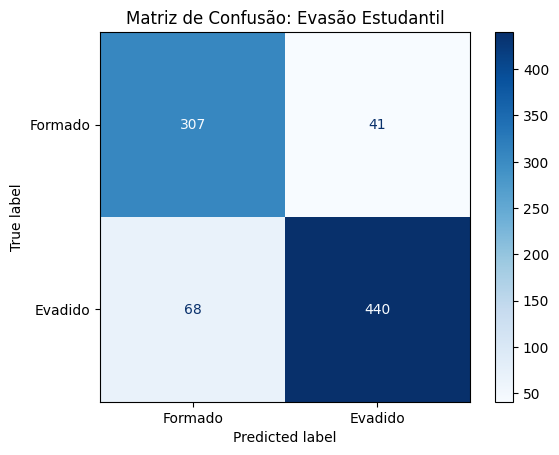

In [476]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = cat.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("\n--- Métricas Detalhadas ---")
print(classification_report(y_test, y_pred, target_names=['Formado (0)', 'Evadido (1)']))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Formado', 'Evadido'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão: Evasão Estudantil')
plt.show()

In [487]:
type(cat)

catboost.core.CatBoostClassifier

In [478]:
feature_importance = cat.get_feature_importance()
feature_importance.sort()
feature_names = X.columns

# Display feature importance
for name, importance in zip(feature_names, feature_importance):
    print(f"Feature: {name}, Importance: {importance:.2f}")

Feature: AnoSem, Importance: 0.56
Feature: Período ingresso, Importance: 0.56
Feature: Estrutura, Importance: 0.73
Feature: Reprovação_Media_Semestral, Importance: 0.87
Feature: Tempo_Permanencia_Em_Semestres, Importance: 1.12
Feature: Total_creditos_estrutura, Importance: 1.14
Feature: Total_Creditos_Acumulados, Importance: 1.47
Feature: Idade_Academica, Importance: 1.47
Feature: Lag_Academico_Em_Semestres, Importance: 1.49
Feature: Lag_Academico_Delta, Importance: 1.53
Feature: Coeficiente_Rendimento, Importance: 1.76
Feature: Coeficiente_Rendimento_Delta, Importance: 1.82
Feature: Modalidade_Ensino, Importance: 2.41
Feature: Eficiencia_Academica, Importance: 2.72
Feature: Eficiencia_Academica_Lag_03, Importance: 2.89
Feature: Eficiencia_Academica_Lag_02, Importance: 3.07
Feature: Eficiencia_Academica_Lag_01, Importance: 4.19
Feature: Rolling_Reprovacao_Media_3_Semestres, Importance: 5.11
Feature: Total_Falhas_Gatekeeper_Acumulado, Importance: 6.42
Feature: Frequencia_Trend, Importan

In [450]:
feats = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

feats = feats.sort_values(by='Importance', ascending=False)
feats.to_csv('features_importance.csv', index=False)

In [451]:
# get the latest column of the active student
df_inference = df_full_sorted_ativos.sort_values(['RGA_Anon', 'Tempo_Permanencia_Em_Semestres'])
df_latest_active = df_inference.groupby('RGA_Anon').tail(1).copy()

# same cleaning for the training
cat_features = X_train.columns[X_train.dtypes == 'object'].tolist() # Ou a lista que você usou
df_latest_active[cat_features] = df_latest_active[cat_features].fillna("Nao_Informado").astype(str)

# align columns
X_inference = df_latest_active[X_train.columns]

In [452]:
from catboost import Pool


inference_pool = Pool(
    data=X_inference, 
    cat_features=cat_features
)


probabilities = cat.predict_proba(inference_pool)[:, 1]

shap_values = cat.get_feature_importance(
    data=inference_pool, 
    type="ShapValues"
)


In [453]:
# ranking
df_ranking = pd.DataFrame({
    'RGA_Anon': df_latest_active['RGA_Anon'],
    'Probabilidade_Evasao': probabilities
}).sort_values(by='Probabilidade_Evasao', ascending=False)

df_ranking['Nivel_Alerta'] = pd.cut(
    df_ranking['Probabilidade_Evasao'], 
    bins=[0, 0.4, 0.7, 1.0], 
    labels=['Baixo', 'Moderado', 'Critico']
)

print(df_ranking.head(10))

                                               RGA_Anon  Probabilidade_Evasao  \
2021  8346f4265b94e141edc60f04aacbf4576a0cd55985633c...              0.997015   
3333  dc71ed5e7a7f9818ad4046fad676efa3cbd4af607e3d6e...              0.996946   
3307  dbd5eaab24bfd494bef913ac1238a8da581fdd481f1a61...              0.996940   
2431  a2735f090fd8ac8270354b064b1a2a943fb63700847420...              0.996915   
494   1dc8f7eafa7a59825e380fa1016d7107373303149f4825...              0.996526   
319   13042e6587b26a168e23d570a87b8584fc5c546827156f...              0.996274   
1423  598101ea7048e667fcbb1f3d7dea1576a0901b5113424d...              0.996172   
3541  e93914c3846a969d393516659592dcbf350446417c7a0b...              0.996120   
3756  f7b1566071658dfa5835c6b0f4d76b3782c788d0384aa9...              0.995977   
3252  d610c05e91a6e16930ec70c8157c33d8128c1b6a4a5ee8...              0.995845   

     Nivel_Alerta  
2021      Critico  
3333      Critico  
3307      Critico  
2431      Critico  
494     

In [454]:
df_ranking.info()

<class 'pandas.core.frame.DataFrame'>
Index: 181 entries, 2021 to 1656
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   RGA_Anon              181 non-null    object  
 1   Probabilidade_Evasao  181 non-null    float64 
 2   Nivel_Alerta          181 non-null    category
dtypes: category(1), float64(1), object(1)
memory usage: 4.5+ KB


In [456]:
#df_ranking.iloc[188, 0]

In [457]:
k = df_ranking.groupby('Nivel_Alerta').size().reset_index()
k

/tmp/ipykernel_9/3677651213.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  k = df_ranking.groupby('Nivel_Alerta').size().reset_index()


,Nivel_Alerta,0
0,Baixo,40
1,Moderado,30
2,Critico,111


In [1099]:
rga = df_ranking.iloc[188, 0]
rga

'416e6abdde840652dae9ee6d17fff33e808ee8a7364d333f9a69405cf75f5e88'

In [1100]:
aluno = df_history_v14 [df_history_v14['RGA_Anon'] ==rga]
aluno

,CH,Crédito,Nota,Situação,Nome_Disciplina,Semestre,Frequencia,Falta_Excessiva,Percentual_Faltas,Qtd_Disciplinas_Semestre,Total_CH_Semestre,MG_Semestre,RGA_Anon,Parcela,AnoSem,Período ingresso,Estrutura,Situação atual,Reprovacao_Ponderada_Semestral,Reprovação_Media_Semestral,Tempo_Permanencia_Em_Semestres,Total_creditos_estrutura,Total_Creditos_Acumulados,Idade_Academica,Lag_Academico,Lag_Academico_Em_Semestres,Lag_Academico_Delta,Coeficiente_Rendimento,Coeficiente_Rendimento_Delta,Modalidade_Ensino,Eficiencia_Academica,Eficiencia_Academica_Lag_03,Eficiencia_Academica_Lag_02,Eficiencia_Academica_Lag_01,Rolling_Reprovacao_Media_3_Semestres,Reprovou_Gatekeeper_Puro,Total_Falhas_Gatekeeper_Acumulado,Frequencia_Trend,Frequencia_Rolling_3S
5410,96,6,0.11,1,CALCULO I,1,89.583333,0,0.104167,6,352,5.468333,416e6abdde840652dae9ee6d17fff33e808ee8a7364d33...,0.1,2022.1,2022.1,20241,MATRICULADO NO PERÍODO,6.0,0.272727,1.0,210,22,0.838095,0.161905,0.161905,0.000000,4.719091,0.000000,Hibrido,0.838095,NaN,NaN,NaN,0.272727,1,1,NaN,96.180556
5411,64,4,6.83,0,PROGRAMACAO DE COMPUTADORES,1,100.000000,0,0.000000,6,352,5.468333,416e6abdde840652dae9ee6d17fff33e808ee8a7364d33...,0.1,2022.1,2022.1,20241,MATRICULADO NO PERÍODO,6.0,0.272727,1.0,210,22,0.838095,0.161905,0.161905,0.000000,4.719091,0.000000,Hibrido,0.838095,NaN,NaN,NaN,0.272727,0,1,NaN,96.180556
5412,64,4,6.45,0,LOGICA DIGITAL,1,93.750000,0,0.062500,6,352,5.468333,416e6abdde840652dae9ee6d17fff33e808ee8a7364d33...,0.1,2022.1,2022.1,20241,MATRICULADO NO PERÍODO,6.0,0.272727,1.0,210,22,0.838095,0.161905,0.161905,0.000000,4.719091,0.000000,Hibrido,0.838095,NaN,NaN,NaN,0.272727,0,1,NaN,96.180556
5413,32,2,7.91,0,INTRODUCAO A COMPUTACAO,1,100.000000,0,0.000000,6,352,5.468333,416e6abdde840652dae9ee6d17fff33e808ee8a7364d33...,0.1,2022.1,2022.1,20241,MATRICULADO NO PERÍODO,6.0,0.272727,1.0,210,22,0.838095,0.161905,0.161905,0.000000,4.719091,0.000000,Hibrido,0.838095,NaN,NaN,NaN,0.272727,0,1,NaN,96.180556
5414,64,4,5.60,0,GEOMETRIA ANALITICA E VETORIAL,1,93.750000,0,0.062500,6,352,5.468333,416e6abdde840652dae9ee6d17fff33e808ee8a7364d33...,0.1,2022.1,2022.1,20241,MATRICULADO NO PERÍODO,6.0,0.272727,1.0,210,22,0.838095,0.161905,0.161905,0.000000,4.719091,0.000000,Hibrido,0.838095,NaN,NaN,NaN,0.272727,0,1,NaN,96.180556
5415,32,2,5.91,0,ELETRONICA BASICA,1,100.000000,0,0.000000,6,352,5.468333,416e6abdde840652dae9ee6d17fff33e808ee8a7364d33...,0.1,2022.1,2022.1,20241,MATRICULADO NO PERÍODO,6.0,0.272727,1.0,210,22,0.838095,0.161905,0.161905,0.000000,4.719091,0.000000,Hibrido,0.838095,NaN,NaN,NaN,0.272727,0,1,NaN,96.180556
5416,64,4,7.00,0,TOPICOS AVANCADOS DE ENGENHARIA DE SOFTWARE (OPT),2,87.500000,0,0.125000,7,448,6.614286,416e6abdde840652dae9ee6d17fff33e808ee8a7364d33...,0.2,2022.2,2022.1,20241,MATRICULADO NO PERÍODO,4.0,0.142857,2.0,210,50,1.904762,0.095238,0.095238,-0.066667,5.770000,1.050909,Hibrido,0.952381,NaN,NaN,0.838095,0.207792,0,1,0.694444,96.527778
5417,96,6,7.55,0,ESTRUTURA DE DADOS I,2,100.000000,0,0.000000,7,448,6.614286,416e6abdde840652dae9ee6d17fff33e808ee8a7364d33...,0.2,2022.2,2022.1,20241,MATRICULADO NO PERÍODO,4.0,0.142857,2.0,210,50,1.904762,0.095238,0.095238,-0.066667,5.770000,1.050909,Hibrido,0.952381,NaN,NaN,0.838095,0.207792,0,1,0.694444,96.527778
5418,64,4,4.50,1,ENGENHARIA DE SOFTWARE,2,90.625000,0,0.093750,7,448,6.614286,416e6abdde840652dae9ee6d17fff33e808ee8a7364d33...,0.2,2022.2,2022.1,20241,MATRICULADO NO PERÍODO,4.0,0.142857,2.0,210,50,1.904762,0.095238,0.095238,-0.066667,5.770000,1.050909,Hibrido,0.952381,NaN,NaN,0.838095,0.207792,0,1,0.694444,96.527778
5419,64,4,5.23,0,ARQUITETURA DE COMPUTADORES,2,100.000000,0,0.000000,7,448,6.614286,416e6abdde840652dae9ee6d17fff33e808ee8a7364d33...,0.2,2022.2,2022.1,20241,MATRICULADO NO PERÍODO,4.0,0.142857,2.0,210,50,1.904762,0.095238,0.095238,-0.066667,5.770000,1.050909,Hibrido,0.952381,NaN,NaN,0.838095,0.207792,0,1,0.694444,96.527778


In [ ]:
aluno[['Lag_Academico_Em_Semestres', '']]

,Lag_Academico_Em_Semestres
9900,0.238095
9901,0.238095
9902,0.238095
9903,0.238095
9904,0.238095
